In [27]:
# ====================================
# Import Libraries
# ====================================

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
connection = sqlite3.connect('../database/fleetpulse.db')
print("Connected successfully")

Connected successfully


In [29]:
# ====================================
# Query: Top 10 Drivers by Trips
# ====================================

query = """
SELECT
    d.full_name,
    COUNT(t.trip_id) AS trip_count
FROM Drivers d
JOIN Trips t
ON d.driver_id = t.driver_id
GROUP BY d.driver_id, d.full_name
ORDER BY trip_count DESC
LIMIT 10;
"""

drivers_df = pd.read_sql_query(query, connection)

drivers_df

,full_name,trip_count
0,Samantha Lawrence,17
1,Dylan Kelley,15
2,Dylan Figueroa,15
3,Brittany Chen,15
4,Dale Stevens,15
5,Brenda Crawford,15
6,Alexander Hudson,15
7,Nasser Alzahrani,14
8,Jonathan Salas,14
9,Julia Wiggins,14


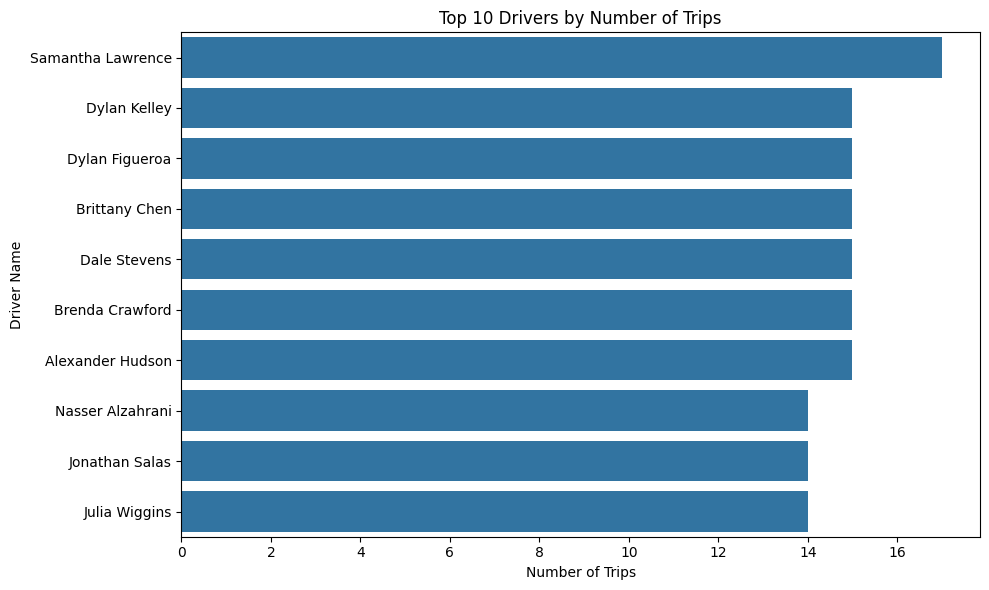

In [30]:
# ====================================
# Visualization: Top Drivers
# ====================================

plt.figure(figsize=(10,6))

sns.barplot(
    data=drivers_df,
    x="trip_count",
    y="full_name"
)

plt.title("Top 10 Drivers by Number of Trips")
plt.xlabel("Number of Trips")
plt.ylabel("Driver Name")

plt.tight_layout()

plt.show()

In [31]:
# ====================================
# Query: Fuel Consumption per Vehicle
# ====================================

query = """
SELECT
    vehicle_id,
    SUM(liters_filled) AS total_fuel
FROM Fuel_Logs
GROUP BY vehicle_id
ORDER BY total_fuel DESC
LIMIT 10;
"""

fuel_df = pd.read_sql_query(query, connection)

fuel_df

,vehicle_id,total_fuel
0,23,7916.16
1,29,7034.49
2,24,7008.98
3,7,6985.32
4,38,6934.43
5,5,6833.89
6,6,6640.19
7,18,6570.23
8,43,6318.92
9,10,6134.13


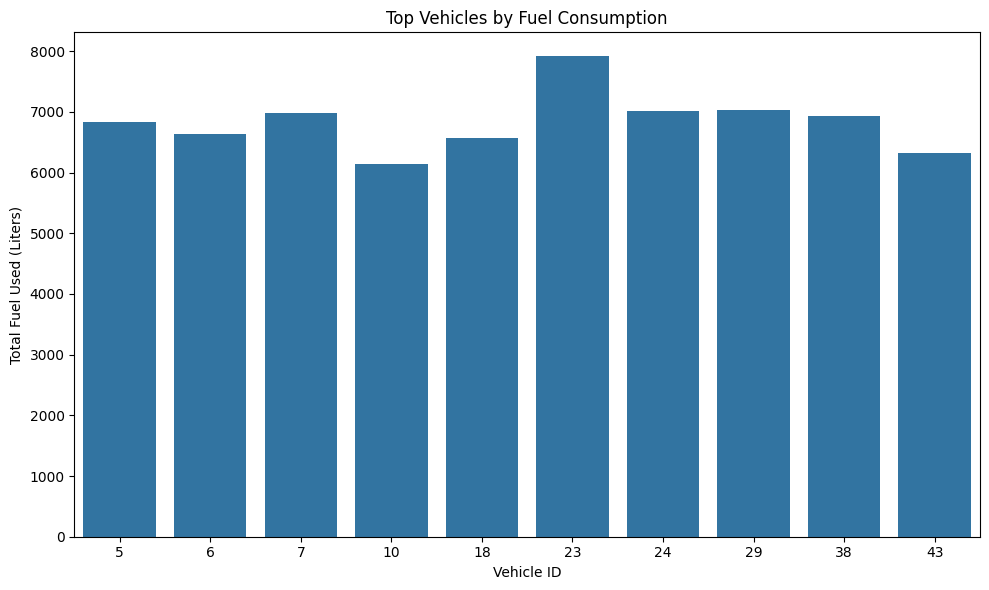

In [32]:
# ====================================
# Visualization: Fuel Consumption
# ====================================

plt.figure(figsize=(10,6))

sns.barplot(
    data=fuel_df,
    x="vehicle_id",
    y="total_fuel"
)

plt.title("Top Vehicles by Fuel Consumption")
plt.xlabel("Vehicle ID")
plt.ylabel("Total Fuel Used (Liters)")

plt.tight_layout()

plt.show()

In [34]:
# ====================================
# Query: Maintenance Cost per Vehicle
# ====================================

query = """
SELECT
    vehicle_id,
    SUM(cost) AS total_maintenance_cost
FROM Maintenance
GROUP BY vehicle_id
ORDER BY total_maintenance_cost DESC
LIMIT 10;
"""

maintenance_df = pd.read_sql_query(query, connection)

maintenance_df

,vehicle_id,total_maintenance_cost
0,16,40671.68
1,44,40238.11
2,9,33376.06
3,12,32939.20
4,14,32288.08
5,27,31950.47
6,47,31484.37
7,49,29283.55
8,15,26591.72
9,26,25751.29


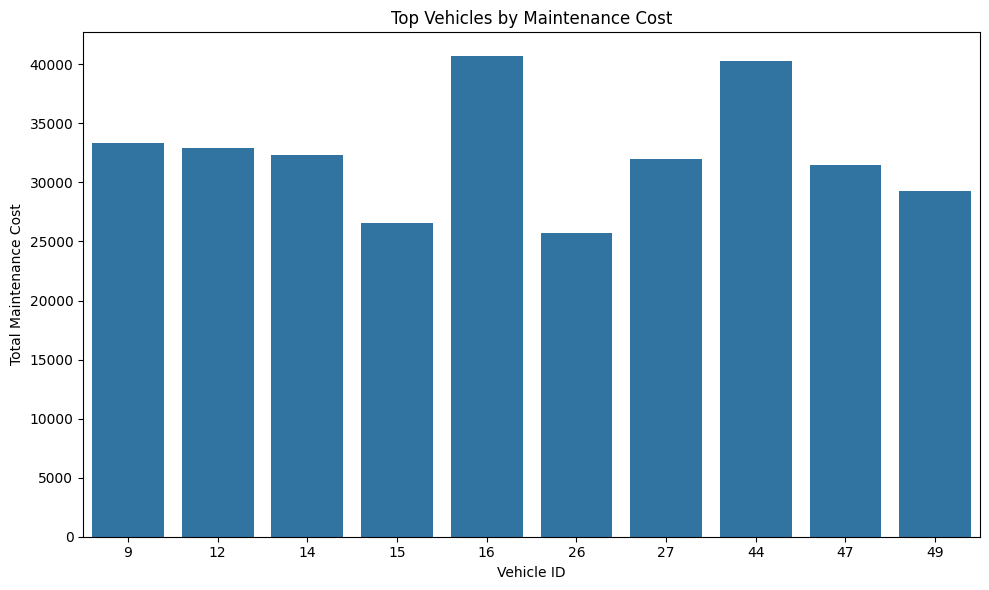

In [ ]:
# ====================================
# Visualization: Maintenance Cost
# ====================================

plt.figure(figsize=(10,6))

sns.barplot(
    data=maintenance_df,
    x="vehicle_id",
    y="total_maintenance_cost"
)

plt.title("Top Vehicles by Maintenance Cost")
plt.xlabel("Vehicle ID")
plt.ylabel("Total Maintenance Cost")

plt.tight_layout()

plt.show()


In [36]:
# ====================================
# Query: Most Used Routes
# ====================================

query = """
SELECT
    r.origin_city,
    r.destination_city,
    COUNT(t.trip_id) AS trip_count
FROM Trips t
JOIN Routes r
ON t.route_id = r.route_id
GROUP BY r.origin_city, r.destination_city
ORDER BY trip_count DESC
LIMIT 10;
"""

routes_df = pd.read_sql_query(query, connection)

routes_df

,origin_city,destination_city,trip_count
0,Riyadh,Jeddah,89
1,Medina,Tabuk,46
2,Riyadh,Jubail,46
3,Riyadh,Najran,46
4,Tabuk,Sakaka,46
5,Dammam,Al Ahsa,43
6,Dammam,Riyadh,42
7,Mecca,Taif,41
8,Riyadh,Hail,40
9,Abha,Jizan,39


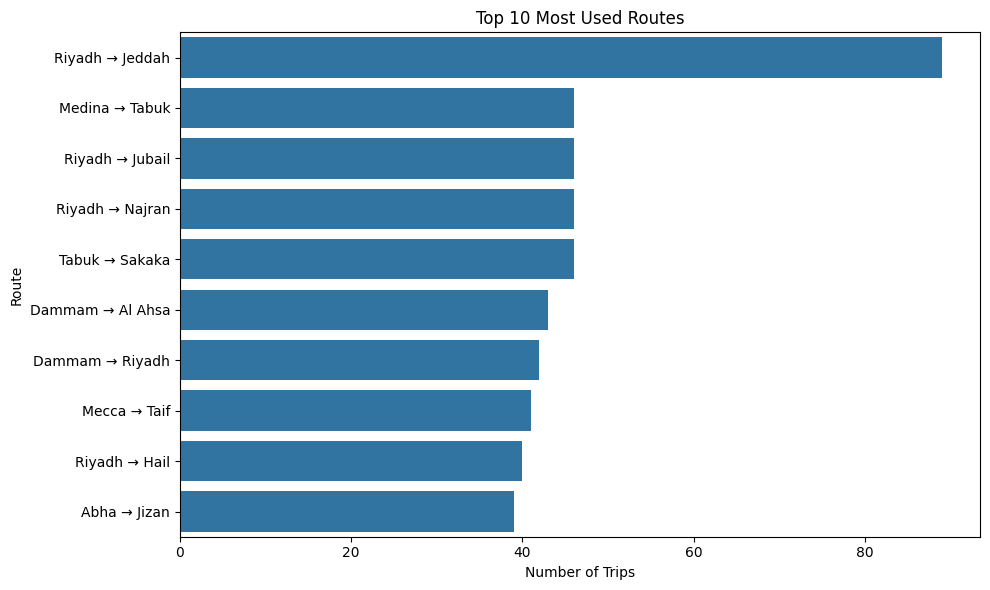

In [37]:
# إنشاء اسم المسار
routes_df["route"] = routes_df["origin_city"] + " → " + routes_df["destination_city"]

plt.figure(figsize=(10,6))

sns.barplot(
    data=routes_df,
    x="trip_count",
    y="route"
)

plt.title("Top 10 Most Used Routes")
plt.xlabel("Number of Trips")
plt.ylabel("Route")

plt.tight_layout()

plt.show()

In [38]:
# ====================================
# Query: Trip Status Distribution
# ====================================

query = """
SELECT
    trip_status,
    COUNT(*) AS trip_count
FROM Trips
GROUP BY trip_status
"""

status_df = pd.read_sql_query(query, connection)

status_df

,trip_status,trip_count
0,Cancelled,307
1,Completed,354
2,Delayed,340


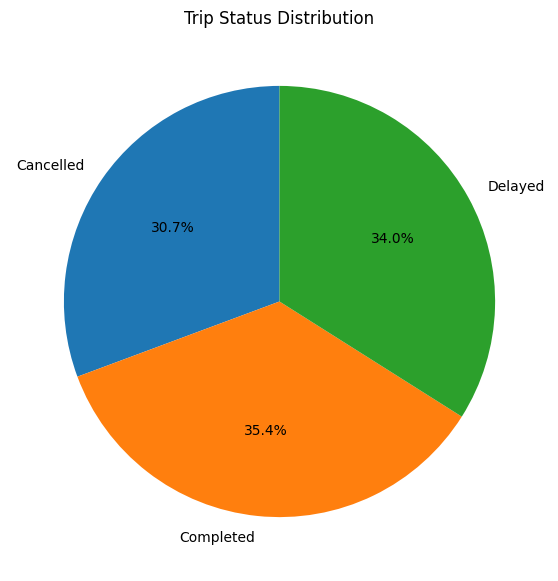

In [39]:
# ====================================
# Visualization: Trip Status Distribution
# ====================================

plt.figure(figsize=(7,7))

plt.pie(
    status_df["trip_count"],
    labels=status_df["trip_status"],
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Trip Status Distribution")

plt.show()

In [46]:
# ====================================
# Query: Violation Types Distribution
# ====================================

query = """
SELECT
    violation_type,
    COUNT(*) AS violation_count
FROM Violations
GROUP BY violation_type
ORDER BY violation_count DESC
"""

violations_df = pd.read_sql_query(query, connection)

violations_df

,violation_type,violation_count
0,Overloading,65
1,Unsafe Driving,50
2,Parking Violation,47
3,Documentation Issue,47
4,Speeding,46
5,Signal Violation,46


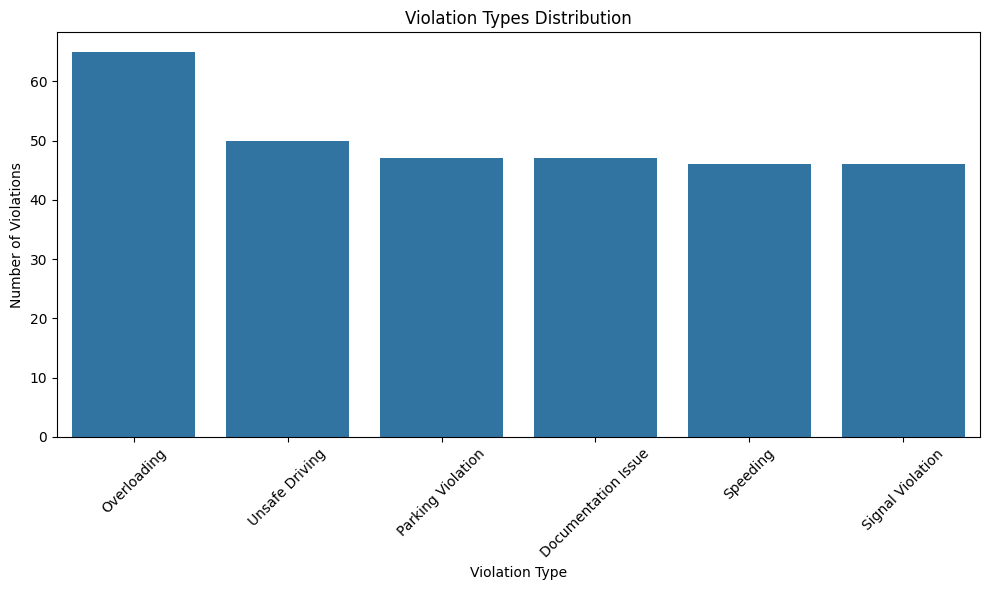

In [41]:
# ====================================
# Visualization: Violation Types
# ====================================

plt.figure(figsize=(10,6))

sns.barplot(
    data=violations_df,
    x="violation_type",
    y="violation_count"
)

plt.title("Violation Types Distribution")
plt.xlabel("Violation Type")
plt.ylabel("Number of Violations")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

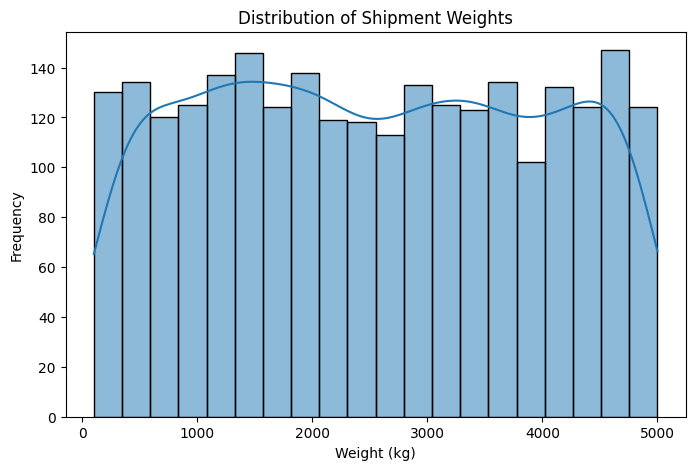

In [43]:
query = "SELECT weight_kg FROM Shipments"
weights_df = pd.read_sql_query(query, connection)

plt.figure(figsize=(8,5))
sns.histplot(weights_df["weight_kg"], bins=20, kde=True)

plt.title("Distribution of Shipment Weights")
plt.xlabel("Weight (kg)")
plt.ylabel("Frequency")
plt.show()

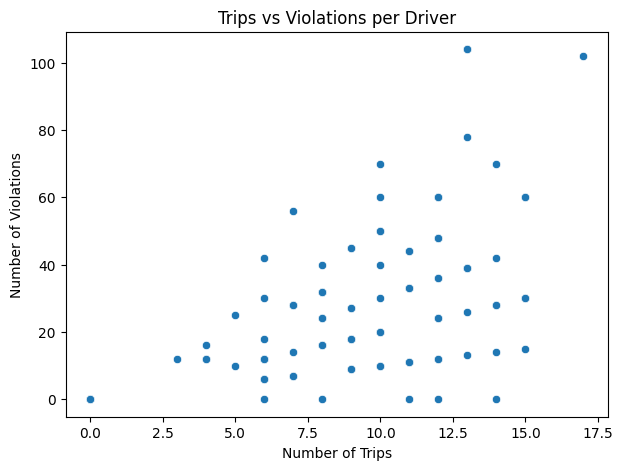

In [45]:
query = """
SELECT
    d.driver_id,
    COUNT(DISTINCT t.trip_id) AS trips,
    COUNT(v.violation_id) AS violations
FROM Drivers d
LEFT JOIN Trips t ON d.driver_id = t.driver_id
LEFT JOIN Violations v ON d.driver_id = v.driver_id
GROUP BY d.driver_id
"""

driver_df = pd.read_sql_query(query, connection)

plt.figure(figsize=(7,5))
sns.scatterplot(data=driver_df, x="trips", y="violations")

plt.title("Trips vs Violations per Driver")
plt.xlabel("Number of Trips")
plt.ylabel("Number of Violations")
plt.show()